Serial communication established on /dev/tty.usbserial-1420 with baud rate 115200
Sending ECG and PPG data to ESP32 in chunks of 1024...
Sending chunk 1 of ECG and PPG data to ESP32...
Receiving FFT results from ESP32...


SerialException: read failed: [Errno 6] Device not configured

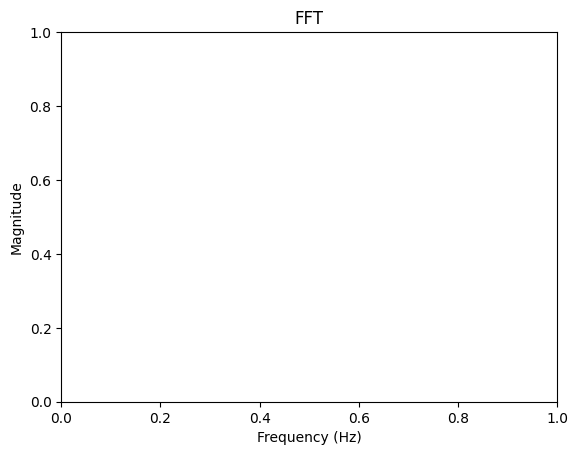

In [ ]:
import serial
import csv
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

# Serial Communication Configuration
esp32_port = "/dev/tty.usbserial-1420"  # Change this to your ESP32's port
baud_rate = 115200
SAMPLES = 1024  # Must match ESP32's SAMPLES
fs = 125  # Sampling frequency in Hz
timeout = 2  # Timeout for serial communication in seconds

# Connect to ESP32
try:
    ser = serial.Serial(esp32_port, baud_rate, timeout=timeout)
    print(f"Serial communication established on {esp32_port} with baud rate {baud_rate}")
except Exception as e:
    print(f"Failed to open serial port {esp32_port}: {e}")
    exit()

# Read Healthy PPG and ECG Data
healthy_paths = []
for dirname, _, filenames in os.walk('/Users/sarahalabdulrazzak/Desktop/Capstone/myenv/Data/mimic_perform_non_af_csv'):
    for filename in filenames:
        if "csv" in filename:
            healthy_paths.append(os.path.join(dirname, filename))

# Select a random healthy patient
if not healthy_paths:
    print("Error: No healthy patient data found.")
    exit()

selected_path = np.random.choice(healthy_paths)
print(f"Selected healthy patient data: {selected_path}")

# Load ECG and PPG Data
df = pd.read_csv(selected_path)
if 'PLETH' in df.columns:
    ppg_signal = df['PLETH'].values
elif 'PPG' in df.columns:
    ppg_signal = df['PPG'].values
else:
    print("Error: No PPG signal found in selected file.")
    exit()

if 'ECG' in df.columns:
    ecg_signal = df['ECG'].values
else:
    print("Error: No ECG signal found in selected file.")
    exit()

# Resample PPG and ECG Signals (if needed)
def resample(signal, fs_original=125, fs_new=125):
    """Resamples a signal using linear interpolation."""
    if fs_original == fs_new:
        return signal  # No resampling needed
    original_time = np.arange(len(signal)) / fs_original
    new_time = np.arange(0, original_time[-1], 1/fs_new)
    interp_function = interp1d(original_time, signal, kind='linear', fill_value='extrapolate')
    return interp_function(new_time)

ppg_signal = resample(ppg_signal, fs_original=125, fs_new=fs)
ecg_signal = resample(ecg_signal, fs_original=125, fs_new=fs)

# Send ECG and PPG Data in Chunks
fft_results = []
print(f"Sending ECG and PPG data to ESP32 in chunks of {SAMPLES}...")

plt.figure()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT")

# Sending ECG and PPG Data
for i in range(0, len(ppg_signal), SAMPLES):
    ppg_chunk = ppg_signal[i:i + SAMPLES]
    ecg_chunk = ecg_signal[i:i + SAMPLES]
    
    if len(ppg_chunk) < SAMPLES or len(ecg_chunk) < SAMPLES:
        print(f"Warning: Remaining data chunk has less than {SAMPLES} samples, skipping.")
        break

    print(f"Sending chunk {i//SAMPLES + 1} of ECG and PPG data to ESP32...")

    # Send ECG Data
    for value in ecg_chunk:
        try:
            ser.write(f"E{value}\n".encode())  # Send ECG data with 'E' prefix
            time.sleep(0.008)  # Small delay to ensure data is sent
        except Exception as e:
            print(f"Error while sending ECG data to ESP32: {e}")
            break

    # Send PPG Data
    for value in ppg_chunk:
        try:
            ser.write(f"P{value}\n".encode())  # Send PPG data with 'P' prefix
            time.sleep(0.008)  # Small delay to ensure data is sent
        except Exception as e:
            print(f"Error while sending PPG data to ESP32: {e}")
            break

    # Receive FFT Results from ESP32
    fft_chunk = []
    peaks_x = []
    peaks_y = []
    print("Receiving FFT results from ESP32...")

    # Receive FFT Results (frequency, magnitude)
    while True:
        line = ser.readline().decode().strip()
        if line == "Printing Peaks":
            break  # End of FFT data, peaks start here
        if line:
            try:
                frequency, magnitude = map(float, line.split(","))
                fft_chunk.append((frequency, magnitude))
            except ValueError:
                print(f"Warning: Could not parse FFT result line: {line}. Skipping this line.")

    # Receive Peaks Data
    while True:
        line = ser.readline().decode().strip()
        if line == "End":
            break  # End of peak data
        if line:
            try:
                frequency, magnitude = map(float, line.split(","))
                peaks_x.append(frequency)
                peaks_y.append(magnitude)
            except ValueError:
                print(f"Warning: Could not parse peak result line: {line}. Skipping this line.")

    # Extract FFT frequencies and magnitudes
    x = [freq for freq, _ in fft_chunk]
    y = [mag for _, mag in fft_chunk]

    # Detect valleys (local minima)
    peaks, _ = find_peaks(y, prominence=0.1, distance=5)  # Detect peaks
    valleys, _ = find_peaks(-np.array(y), prominence=0.1, distance=5)  # Detect valleys

    valleys_x = [x[v] for v in valleys]
    valleys_y = [y[v] for v in valleys]

    # Plot the FFT data
    plt.cla()
    plt.plot(x, y, color='b', label="FFT")  # FFT data in blue
    plt.scatter(peaks_x, peaks_y, color='r', label="Peaks")  # Peaks in red
    plt.scatter(valleys_x, valleys_y, color='g', label="Valleys")  # Valleys in green
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim([0, 20])
    plt.title("FFT of ECG and PPG with Peaks and Valleys")
    plt.legend()
    plt.pause(0.1)  # Pause to update the plot

    fft_results.extend(fft_chunk)

plt.close()
